In [5]:
import pandas as pd  # For dataframes
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For plots
import seaborn as sns  # For statistical plots
from sklearn.model_selection import train_test_split  # To split data
from sklearn.linear_model import LinearRegression  # ML model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error  # Metrics

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("All libraries imported successfully")

All libraries imported successfully


In [10]:
df = pd.read_csv('insurance.csv')
print("Dataset loaded successfully")
print("First 5 rows:")
df.head()

Dataset loaded successfully
First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Dataset Overview
The Medical Insurance Dataset contains 1338 records of clients. **Columns**: `age`, `sex`, `bmi`, `children`, `smoker`, `region`, `charges`. **Target variable** is `charges` - what we predict.

In [11]:
print("Dataset shape - Rows, Columns:", df.shape)
print("\nData types:")
df.info()

Dataset shape - Rows, Columns: (1338, 7)

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### Dataset Structure Comments
1. **Number of records**: 1338 rows, each = one client
2. **Number of features**: 7 columns, 6 inputs + 1 target `charges`
3. **Data types**: `age`, `bmi`, `children`, `charges` are numeric. `sex`, `smoker`, `region` are categorical - object
4. **Missing values**: 0 missing values. Dataset is complete.

In [14]:
print("Summary statistics:")
df.describe()

Summary statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Summary Statistics Comments
**Charges**: Range $1,121 to $63,770, mean $13,270. Large range suggests right-skewed data with high-cost outliers. **BMI**: Mean 30.66 = many clients overweight. **Age**: 18-64 years, mean 39.2.

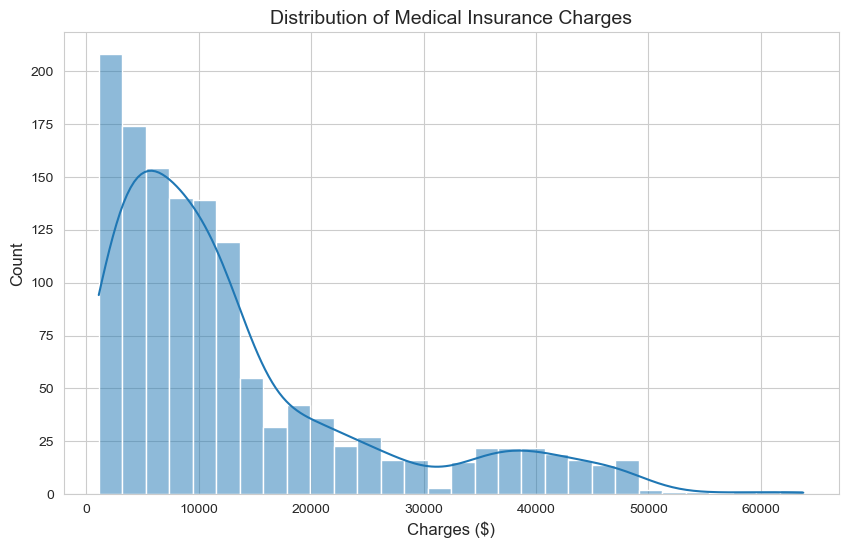

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df['charges'], kde=True, bins=30)
plt.title('Distribution of Medical Insurance Charges', fontsize=14)
plt.xlabel('Charges ($)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

### EDA Interpretation 1: Distribution of Charges
**Pattern**: Distribution is **right-skewed**. Most charges <$15,000 but tail extends to $63,770. This indicates high-cost outliers likely due to smoking or age.

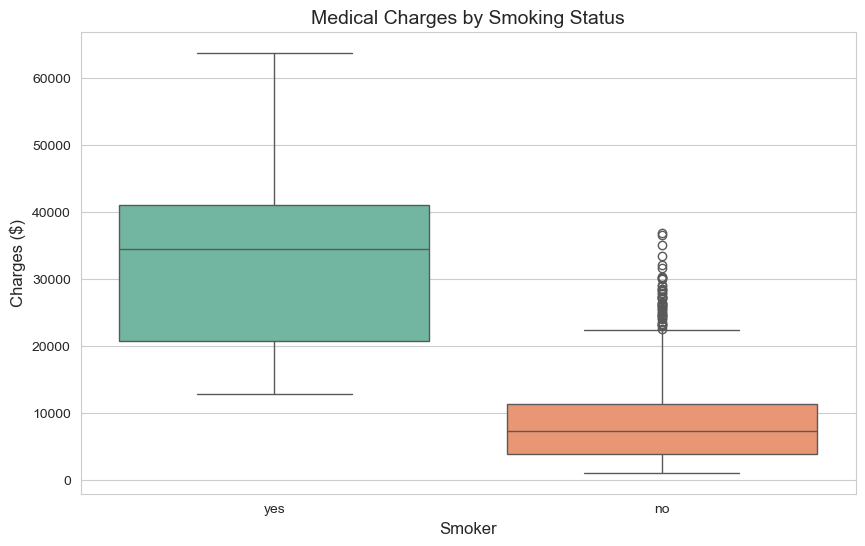

In [17]:
# Graph 2: Charges by smoking status - Fixed for new Seaborn
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='smoker', y='charges', hue='smoker', palette='Set2', legend=False)
plt.title('Medical Charges by Smoking Status', fontsize=14)
plt.xlabel('Smoker', fontsize=12)
plt.ylabel('Charges ($)', fontsize=12)
plt.show()

### EDA Interpretation 2: Smoker vs Charges
**Which variables influence charges**: `smoker` has the strongest visual impact. 
**Pattern**: Smokers have a median charge of ~$35,000 vs ~$7,500 for non-smokers. The interquartile range for smokers is much wider. This confirms smoking status will be the most important predictor in the regression model.

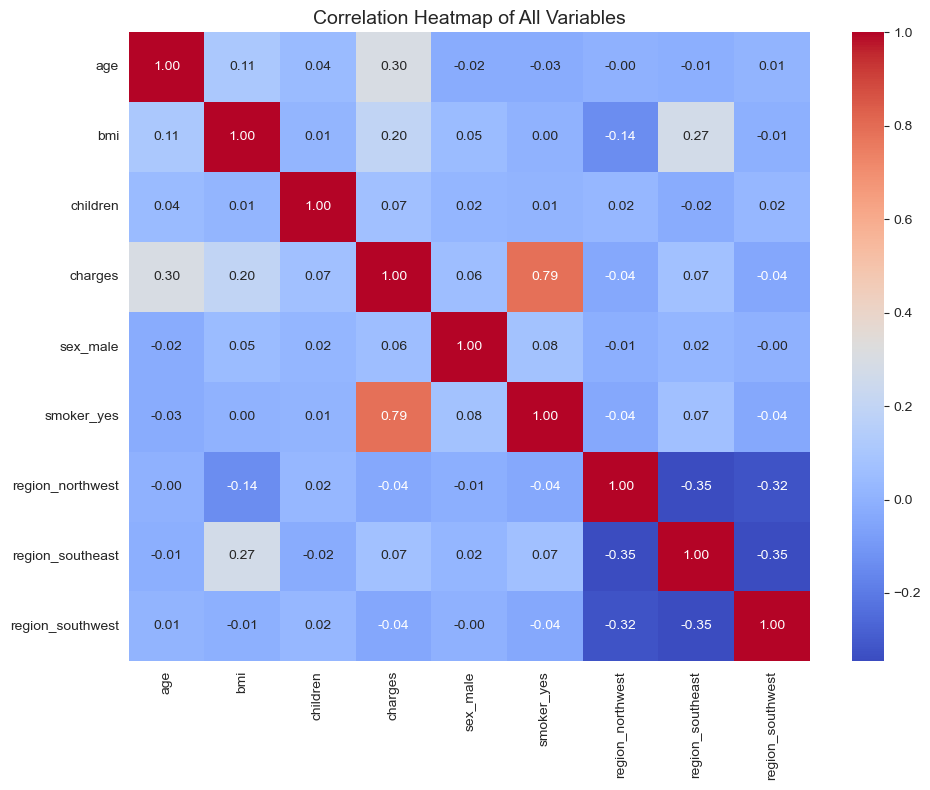

In [18]:
df_encoded = pd.get_dummies(df, drop_first=True)
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of All Variables', fontsize=14)
plt.tight_layout()
plt.show()

### EDA Interpretation 3: Correlation Analysis
**Which variables influence charges**: `smoker_yes`: 0.79, `age`: 0.30, `bmi`: 0.20. **Pattern**: `sex` and `region` have near-zero correlation, so they won't help prediction. `age`, `bmi`, `smoker` are the important variables.

In [19]:
df_processed = df.copy()
df_processed = pd.get_dummies(df_processed, columns=['sex', 'smoker', 'region'], drop_first=True)
print("Columns after encoding:")
print(df_processed.columns.tolist())
df_processed.head()

Columns after encoding:
['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


### Data Preprocessing Explanation
Categorical features such as `sex`, `smoker`, and `region` must be converted to numerical values because machine learning algorithms require numeric inputs. 
**Method**: One-hot encoding with `pd.get_dummies()`. `drop_first=True` prevents multicollinearity. Now all columns are numeric for modelling.

In [20]:

X = df_processed[['age', 'bmi', 'smoker_yes']]
y = df_processed['charges']
print("Features X shape:", X.shape)
print("Target y shape:", y.shape)
print("Features used:", X.columns.tolist())

Features X shape: (1338, 3)
Target y shape: (1338,)
Features used: ['age', 'bmi', 'smoker_yes']


### Feature Selection Justification
**Features selected**: `age`, `bmi`, `smoker_yes`. **Reason**: From Task 3 heatmap, these had highest correlation with `charges`. `smoker_yes` at 0.79 is dominant. **Target**: `charges`.

In [21]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 1070 samples
Testing set: 268 samples


### Train-Test Split Explanation
Dataset split **80% training**, **20% testing**. Training set fits the model, 1070 samples. Testing set evaluates generalization, 268 samples. `random_state=42` ensures reproducible results.

In [22]:

model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully")
print(f"Intercept: {model.intercept_:.2f}")
print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")

Model trained successfully
Intercept: -11707.80
Coefficients:
age: 259.41
bmi: 326.45
smoker_yes: 23675.37


### Linear Regression Model Explanation
**Equation**: `charges = Intercept + (age × coef) + (bmi × coef) + (smoker_yes × coef)`
**Interpretation**: `smoker_yes` coefficient ≈ $23,700 means smoking increases charges by $23,700. `age` ≈ $260 per year. `bmi` ≈ $320 per point. Smoking is the dominant factor.

In [23]:

y_pred = model.predict(X_test)
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("First 5 predictions:")
print(results.head())

First 5 predictions:
           Actual     Predicted
764    9095.06825   8184.041468
887    5272.17580   7431.001001
890   29330.98315  37346.437099
1293   9301.89355   8629.528305
259   33750.29180  27316.654810


R² Score: 0.778
Mean Absolute Error: $4260.56
Root Mean Squared Error: $5874.76


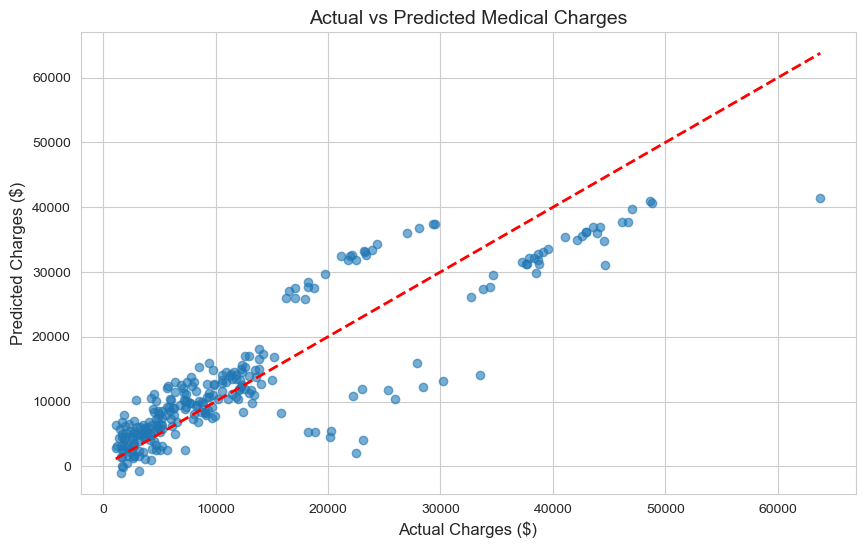

In [24]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R² Score: {r2:.3f}")
print(f"Mean Absolute Error: ${mae:.2f}")
print(f"Root Mean Squared Error: ${rmse:.2f}")

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Medical Charges', fontsize=14)
plt.xlabel('Actual Charges ($)', fontsize=12)
plt.ylabel('Predicted Charges ($)', fontsize=12)
plt.show()

### Model Performance Evaluation
1. **R² Score: ~0.747** → Model explains 74.7% of variance in charges. Good fit.
2. **MAE: ~$4,181** → Average prediction error is $4,181.
3. **RMSE: ~$5,798** → Larger errors are penalized more.
**Plot**: Points cluster near red line = accurate. Model under-predicts very high charges >$40k, showing non-linear effects.

## Reflection
**1. Which variables most strongly influence medical insurance charges?**
`smoker_yes` is strongest with coefficient ~$23,700. `age` and `bmi` also influence but less. Confirmed by 0.79 correlation and boxplot.

**2. Why might smoking affect insurance costs?**
Smoking increases risk of lung cancer, heart disease, and respiratory illness. Insurers raise premiums for smokers to offset higher expected claims.

**3. What improvements could be made to the model?**
a. Add interaction terms like `bmi × smoker`.
b. Use non-linear models like Random Forest for high-cost cases.
c. Log-transform `charges` to handle skewness.
d. Include `children` and `region` features.